"""
Limpiador y Corrector de Dataset MPU-6050
Corrige timestamps duplicados, gaps y resamplea a frecuencia uniforme
"""


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [ ]:
class MPU6050DatasetCleaner:
    """Limpia y corrige datasets del MPU-6050"""

    def __init__(self, target_fs=50):
        """
        Args:
            target_fs: Frecuencia de muestreo objetivo en Hz
        """
        self.target_fs = target_fs
        self.sample_period = 1000 / target_fs  # Periodo en ms

    def load_raw_data(self, filepath):
        """Carga datos crudos desde archivo de texto"""
        try:
            data = pd.read_csv(filepath, sep=r'\s+', header=None,
                             names=['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'Time'])
            print(f"✅ Cargadas {len(data)} muestras del archivo")
            return data
        except Exception as e:
            print(f"❌ Error al cargar archivo: {e}")
            return None

    def analyze_timestamps(self, data):
        """Analiza problemas en los timestamps"""
        time = data['Time'].values

        print("\n" + "="*60)
        print("ANÁLISIS DE TIMESTAMPS")
        print("="*60)

        # 1. Duplicados
        duplicates = np.sum(np.diff(time) == 0)
        print(f"📊 Timestamps duplicados: {duplicates}")

        # 2. Saltos (gaps > 30ms)
        deltas = np.diff(time)
        gaps = np.sum(deltas > 30)
        print(f"📊 Gaps detectados (>30ms): {gaps}")

        # 3. Estadísticas de deltas
        print(f"\n📈 Estadísticas de deltas (ms):")
        print(f"   Media: {np.mean(deltas):.2f}")
        print(f"   Mediana: {np.median(deltas):.2f}")
        print(f"   Mín: {np.min(deltas):.2f}")
        print(f"   Máx: {np.max(deltas):.2f}")
        print(f"   Std: {np.std(deltas):.2f}")

        # 4. Frecuencia real
        duration_sec = (time[-1] - time[0]) / 1000
        real_fs = len(data) / duration_sec
        print(f"\n🎯 Frecuencia real: {real_fs:.2f} Hz")
        print(f"   Duración: {duration_sec:.2f} segundos")

        return {
            'duplicates': duplicates,
            'gaps': gaps,
            'backwards': backwards,
            'real_fs': real_fs,
            'duration': duration_sec
        }

    def fix_duplicate_timestamps(self, data):
        """Corrige timestamps duplicados y gaps siguiendo la secuencia esperada de 20ms"""

        time = data['Time'].values.copy()

        changes = 0

        for i in range(1, len(time)):
            delta = time[i] - time[i-1]

            # Caso 1: Timestamp duplicado (delta = 0)
            if delta == 0:
                time[i] = time[i-1] + self.sample_period
                changes += 1

            # Caso 2: Gap mayor a 20ms (se saltó un timestamp)
            elif delta > self.sample_period:
                # Corregir al timestamp que debería ser
                time[i] = time[i-1] + self.sample_period
                changes += 1

        if changes > 0:
            print(f"🔧 Corregidos {changes} timestamps (duplicados y gaps)")
            data['Time'] = time

        return data


    def resample_uniform(self, data):
        """Resamplea datos a frecuencia uniforme usando interpolación"""

        print(f"\n🔄 Resampling a {self.target_fs}Hz uniforme...")

        # Crear timeline uniforme
        time_start = data['Time'].iloc[0]
        time_end = data['Time'].iloc[-1]
        num_samples = int((time_end - time_start) / self.sample_period) + 1

        time_uniform = np.linspace(time_start, time_end, num_samples)

        # Interpolar cada columna
        data_resampled = pd.DataFrame({'Time': time_uniform})

        for col in ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ']:
            # Interpolación lineal
            f_interp = interp1d(data['Time'], data[col],
                               kind='linear',
                               bounds_error=False,
                               fill_value='extrapolate')

            data_resampled[col] = f_interp(time_uniform)

        print(f"✅ Resampled: {len(data)} → {len(data_resampled)} muestras")
        print(f"   Frecuencia: {self.target_fs:.2f}Hz")
        print(f"   Periodo: {self.sample_period:.2f}ms")

        return data_resampled

    def clean_dataset(self, filepath, output_path=None, plot=True):
        """Pipeline completo de limpieza"""

        print("\n" + "="*60)
        print("LIMPIEZA DE DATASET MPU-6050")
        print("="*60)

        # 1. Cargar datos
        data = self.load_raw_data(filepath)
        if data is None:
            return None

        # 2. Análisis inicial
        stats_before = self.analyze_timestamps(data)

        # 3. Limpieza paso a paso
        print("\n" + "="*60)
        print("APLICANDO CORRECCIONES")
        print("="*60)

        # Paso 1: Corregir timestamps duplicados (SIN eliminar datos)
        data_clean = self.fix_duplicate_timestamps(data)

        # Paso 2: Resamplear a frecuencia uniforme
        data_clean = self.resample_uniform(data_clean)

        # 3. Análisis final
        print("\n" + "="*60)
        print("RESULTADO FINAL")
        print("="*60)
        stats_after = self.analyze_timestamps(data_clean)

        # 4. Guardar archivo limpio
        if output_path:
            data_clean.to_csv(output_path, sep=' ', header=False, index=False, float_format='%.3f')
            print(f"\n💾 Archivo limpio guardado en: {output_path}")

        # 5. Visualización
        if plot:
            self.plot_comparison(data, data_clean, stats_before, stats_after)

        return data_clean

    def plot_comparison(self, data_raw, data_clean, stats_before, stats_after):
        """Genera gráficos de comparación antes/después"""

        fig, axes = plt.subplots(3, 2, figsize=(14, 10))
        fig.suptitle('Comparación: Dataset Original vs Limpio', fontsize=16, fontweight='bold')

        # === COLUMNA IZQUIERDA: ORIGINAL ===

        # 1. Acelerómetro original
        axes[0, 0].plot(data_raw['Time']/1000, data_raw['AccX'], label='AccX', alpha=0.7)
        axes[0, 0].plot(data_raw['Time']/1000, data_raw['AccY'], label='AccY', alpha=0.7)
        axes[0, 0].plot(data_raw['Time']/1000, data_raw['AccZ'], label='AccZ', alpha=0.7)
        axes[0, 0].set_title(f'Original - Acelerómetro ({stats_before["real_fs"]:.1f}Hz)')
        axes[0, 0].set_ylabel('Aceleración (m/s²)')
        axes[0, 0].legend(loc='upper right', fontsize=8)
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Giroscopio original
        axes[1, 0].plot(data_raw['Time']/1000, data_raw['GyrX'], label='GyrX', alpha=0.7)
        axes[1, 0].plot(data_raw['Time']/1000, data_raw['GyrY'], label='GyrY', alpha=0.7)
        axes[1, 0].plot(data_raw['Time']/1000, data_raw['GyrZ'], label='GyrZ', alpha=0.7)
        axes[1, 0].set_title('Original - Giroscopio')
        axes[1, 0].set_ylabel('Velocidad angular (rad/s)')
        axes[1, 0].legend(loc='upper right', fontsize=8)
        axes[1, 0].grid(True, alpha=0.3)

        # 3. Deltas de tiempo original
        deltas_raw = np.diff(data_raw['Time'])
        axes[2, 0].plot(deltas_raw, 'o-', markersize=2, alpha=0.6)
        axes[2, 0].axhline(y=20, color='r', linestyle='--', label='Objetivo: 20ms')
        axes[2, 0].set_title(f'Deltas Tiempo Original (Gaps: {stats_before["gaps"]})')
        axes[2, 0].set_ylabel('Delta (ms)')
        axes[2, 0].set_xlabel('Muestra #')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
        axes[2, 0].set_ylim([-5, 80])

        # === COLUMNA DERECHA: LIMPIO ===

        # 4. Acelerómetro limpio
        axes[0, 1].plot(data_clean['Time']/1000, data_clean['AccX'], label='AccX', alpha=0.7)
        axes[0, 1].plot(data_clean['Time']/1000, data_clean['AccY'], label='AccY', alpha=0.7)
        axes[0, 1].plot(data_clean['Time']/1000, data_clean['AccZ'], label='AccZ', alpha=0.7)
        axes[0, 1].set_title(f'Limpio - Acelerómetro ({stats_after["real_fs"]:.1f}Hz)')
        axes[0, 1].set_ylabel('Aceleración (m/s²)')
        axes[0, 1].legend(loc='upper right', fontsize=8)
        axes[0, 1].grid(True, alpha=0.3)

        # 5. Giroscopio limpio
        axes[1, 1].plot(data_clean['Time']/1000, data_clean['GyrX'], label='GyrX', alpha=0.7)
        axes[1, 1].plot(data_clean['Time']/1000, data_clean['GyrY'], label='GyrY', alpha=0.7)
        axes[1, 1].plot(data_clean['Time']/1000, data_clean['GyrZ'], label='GyrZ', alpha=0.7)
        axes[1, 1].set_title('Limpio - Giroscopio')
        axes[1, 1].set_ylabel('Velocidad angular (rad/s)')
        axes[1, 1].legend(loc='upper right', fontsize=8)
        axes[1, 1].grid(True, alpha=0.3)

        # 6. Deltas de tiempo limpio
        deltas_clean = np.diff(data_clean['Time'])
        axes[2, 1].plot(deltas_clean, 'o-', markersize=2, alpha=0.6, color='green')
        axes[2, 1].axhline(y=20, color='r', linestyle='--', label='Objetivo: 20ms')
        axes[2, 1].set_title(f'Deltas Tiempo Limpio (Uniforme: {self.target_fs}Hz)')
        axes[2, 1].set_ylabel('Delta (ms)')
        axes[2, 1].set_xlabel('Muestra #')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        axes[2, 1].set_ylim([19, 21])  # Zoom para ver uniformidad

        plt.tight_layout()
        plt.savefig('dataset_comparison.png', dpi=300, bbox_inches='tight')
        print(f"\n📊 Gráfico guardado en: dataset_comparison.png")
        plt.show()




LIMPIEZA DE DATASET MPU-6050
✅ Cargadas 3000 muestras del archivo

ANÁLISIS DE TIMESTAMPS
📊 Timestamps duplicados: 291
📊 Gaps detectados (>30ms): 243
📊 Saltos hacia atrás: 0

📈 Estadísticas de deltas (ms):
   Media: 20.00
   Mediana: 20.00
   Mín: 0.00
   Máx: 100.00
   Std: 9.70

🎯 Frecuencia real: 50.02 Hz
   Duración: 59.98 segundos

APLICANDO CORRECCIONES
🔧 Corregidos 343 timestamps (duplicados y gaps)

🔄 Resampling a 50Hz uniforme...
✅ Resampled: 3000 → 3000 muestras
   Frecuencia: 50.00Hz
   Periodo: 20.00ms

RESULTADO FINAL

ANÁLISIS DE TIMESTAMPS
📊 Timestamps duplicados: 0
📊 Gaps detectados (>30ms): 0
📊 Saltos hacia atrás: 0

📈 Estadísticas de deltas (ms):
   Media: 20.00
   Mediana: 20.00
   Mín: 20.00
   Máx: 20.00
   Std: 0.00

🎯 Frecuencia real: 50.02 Hz
   Duración: 59.98 segundos

💾 Archivo limpio guardado en: DATASET_SHIMMY2_CLEAN.txt

📊 Gráfico guardado en: dataset_comparison.png


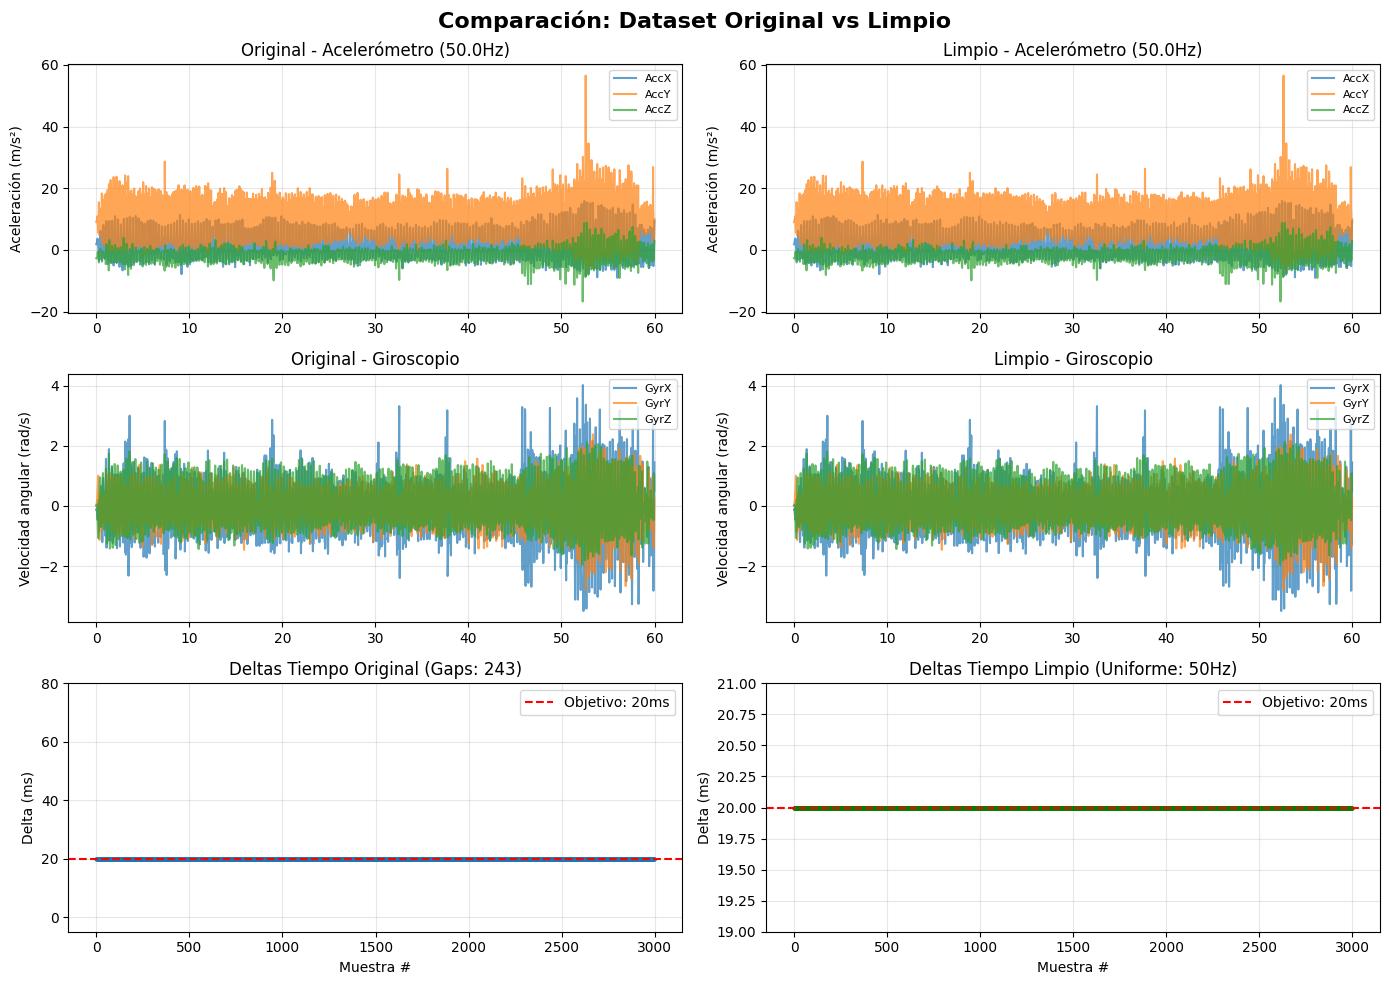


✅ Proceso completado!


In [ ]:

# ============================================
# EJEMPLO DE USO
# ============================================

if __name__ == "__main__":

    # Crear limpiador
    cleaner = MPU6050DatasetCleaner(target_fs=50)

    # Limpiar dataset
    data_clean = cleaner.clean_dataset(
        filepath='DATASET_SHIMMY2',
        output_path='DATASET_SHIMMY2_CLEAN.txt',
        plot=True
    )

    print("\n✅ Proceso completado!")
